# Metrics sensitivity to alternative climate settings

The purpose of this notebook is to assess the sensitivity of the metrics values to various climate parameters.

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.patches import Patch


# Climate functions
from aerocm.metrics.aviation_climate_metrics_calculation import AviationClimateMetricsCalculation

In [2]:
# --- Set parameters ---

## Climate model
climate_model = "FaIR"
start_year = 1940

## Metrics
time_horizon = 100

## Species
species_profile = 'pulse'
profile_start_year = 2020
species_list = ["Contrails"]

# Species settings
species_settings_bickel = {"Contrails": {"ratio_erf_rf": 0.55, "efficacy_erf": 0.38}}
species_settings_teoh = {"Contrails": {"sensitivity_rf": 2.23e-12 * 0.557}}

In [3]:
# --- Calculate metrics ---

results_lee = AviationClimateMetricsCalculation(
    climate_model,
    start_year,
    time_horizon,
    species_profile,
    profile_start_year,
    species_list   
).run()

results_bickel = AviationClimateMetricsCalculation(
    climate_model,
    start_year,
    time_horizon,
    species_profile,
    profile_start_year,
    species_list,
    species_settings=species_settings_bickel
).run()

results_teoh = AviationClimateMetricsCalculation(
    climate_model,
    start_year,
    time_horizon,
    species_profile,
    profile_start_year,
    species_list,
    species_settings=species_settings_teoh
).run()

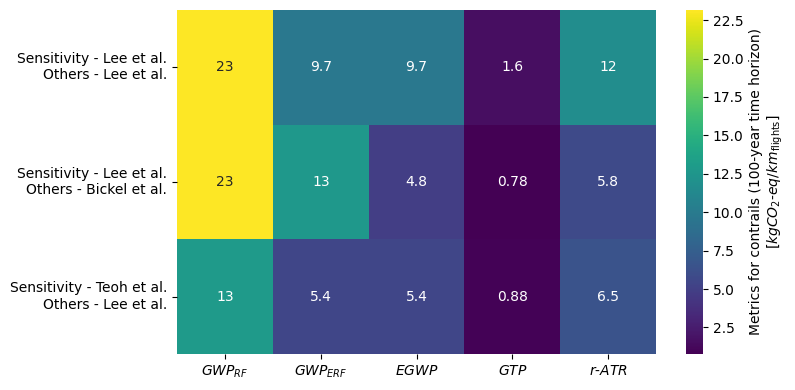

In [4]:
# -- Plot results ---

# Parameters
selected_horizon = 100
species = "Contrails"
selected_metrics = ["gwp_rf", "gwp_erf", "egwp_rf", "gtp", "ratr"]

# Collect data
data = np.zeros((3, len(selected_metrics)))

for k, results in enumerate([results_lee, results_bickel, results_teoh]):
    metrics = results[selected_horizon][species]
    data[k] = [metrics[m] for m in selected_metrics]

# Plot heatmap
metric_labels = [r"$GWP_{RF}$", r"$GWP_{ERF}$", r"$EGWP$", r"$GTP$", r"$r\text{-}ATR$"]
scenario_labels = [
    "Sensitivity - Lee et al.\nOthers - Lee et al.",
    "Sensitivity - Lee et al.\nOthers - Bickel et al.",
    "Sensitivity - Teoh et al.\nOthers - Lee et al."
]

plt.figure(figsize=(8, 4))
sns.heatmap(
    data,
    annot=True,
    cmap="viridis",
    cbar=True,
    xticklabels=metric_labels,
    yticklabels=scenario_labels,
    cbar_kws={
        "label": (
            "Metrics for contrails (100-year time horizon)\n"
            "[$kgCO_2\\text{-}eq/km_{\\text{flights}}$]"
        )
    }
)

# Save plot
plt.tight_layout()
plt.savefig("figures/alternative_settings.pdf")
plt.show()

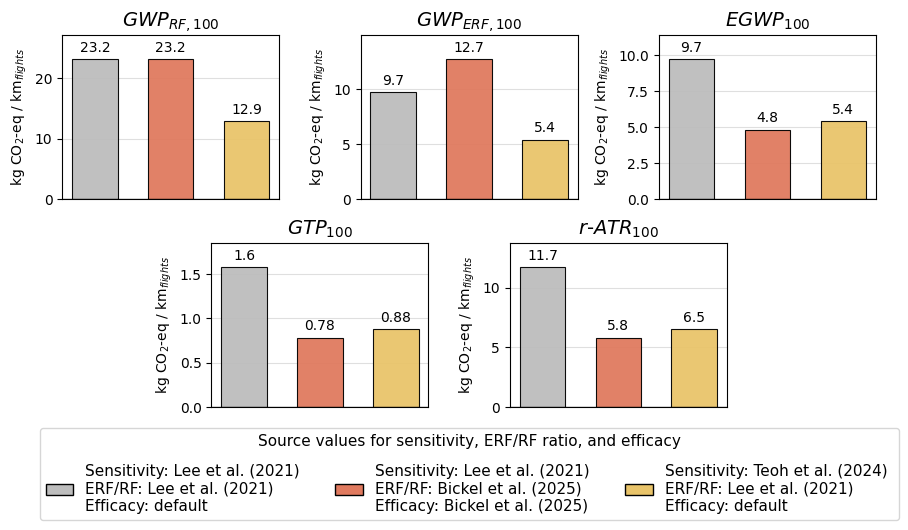

In [83]:
# -- Alternative plot (bars) ---

def plot_contrail_metric_comparison(
    results_by_scenario,
    selected_horizon=100,
    species="Contrails",
    selected_metrics=None,
    metric_labels=None,
    ylabel=r"kg CO$_2$-eq / km$_{flights}$",
    savepath=None,
):

    if selected_metrics is None:
        selected_metrics = ["gwp_rf", "gwp_erf", "egwp_rf", "gtp", "ratr"]

    if metric_labels is None:
        metric_labels = [
            rf"$GWP_{{RF,{selected_horizon}}}$",
            rf"$GWP_{{ERF,{selected_horizon}}}$",
            rf"$EGWP_{{{selected_horizon}}}$",
            rf"$GTP_{{{selected_horizon}}}$",
            rf"$r$-$ATR_{{{selected_horizon}}}$",
        ]

    scenario_names = list(results_by_scenario.keys())
    n_scenarios = len(scenario_names)

    fig = plt.figure(figsize=(10.5, 6.0))

    # Prepare layout
    gs = fig.add_gridspec(
        3, 6,
        height_ratios=[1, 1, 0.28],
        hspace=0.35,
        wspace=1.2,
    )
    
    # First row: 3 panels
    ax1 = fig.add_subplot(gs[0, 0:2])
    ax2 = fig.add_subplot(gs[0, 2:4])
    ax3 = fig.add_subplot(gs[0, 4:6])
    
    # Second row: 2 centered panels
    ax4 = fig.add_subplot(gs[1, 1:3])
    ax5 = fig.add_subplot(gs[1, 3:5])
    
    plot_axes = [ax1, ax2, ax3, ax4, ax5]
    
    # Third row: legend
    legend_ax = fig.add_subplot(gs[2, :])
    legend_ax.axis("off")

    # Bar positions
    x = np.arange(n_scenarios)

    # Styles for the 3 scenarios
    colors = [
        "#BDBDBD",
        "#e07a5f",
        "#e9c46a"
    ]
    hatches = ["", "", ""]
    edgecolor = "black"

    for ax, metric, metric_label in zip(plot_axes, selected_metrics, metric_labels):
        values = [
            results_by_scenario[name][selected_horizon][species][metric]
            for name in scenario_names
        ]

        bars = ax.bar(
            x,
            values,
            width=0.6,
            color=colors[:n_scenarios],
            hatch=hatches[:n_scenarios],
            edgecolor=edgecolor,
            linewidth=0.8,
            alpha=0.95,
        )

        ax.set_title(metric_label, fontsize=14)
        ax.set_xticks([])  # no x-axis labels
        ax.set_ylabel(ylabel)

        ax.axhline(0, color="black", linewidth=1.0, alpha=0.6)
        ax.grid(axis="y", linestyle="-", alpha=0.4)
        ax.set_axisbelow(True)

        # Add numeric labels above bars
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax * 1.12)
        yrange = ymax - ymin if ymax > ymin else 1.0

        for bar, val in zip(bars, values):
            if abs(val) >= 1:
                label = f"{val:.1f}"
            else:
                label = f"{val:.2f}"

            if val >= 0:
                y_text = bar.get_height() + 0.03 * yrange
                va = "bottom"
            else:
                y_text = bar.get_height() - 0.03 * yrange
                va = "top"

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y_text,
                label,
                ha="center",
                va=va,
                fontsize=10,
            )

    # Legend in boxed empty panel
    legend_ax.axis("off")
    handles = [
        Patch(
            facecolor=colors[i],
            edgecolor=edgecolor,
            hatch=hatches[i],
            label=name,
        )
        for i, name in enumerate(scenario_names)
    ]

    legend_ax.legend(
        handles=handles,
        title="Source values for sensitivity, ERF/RF ratio, and efficacy",
        loc="center",
        ncol=3,
        frameon=True,
        labelspacing=1.0,
        columnspacing=2.0,
        handlelength=1.8,
        fontsize=11,
        title_fontsize=11,
    )

    #plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")

    plt.show()


results_by_scenario = {
    "Sensitivity: Lee et al. (2021) \nERF/RF: Lee et al. (2021) \nEfficacy: default": results_lee,
    "Sensitivity: Lee et al. (2021) \nERF/RF: Bickel et al. (2025) \nEfficacy: Bickel et al. (2025)": results_bickel,
    "Sensitivity: Teoh et al. (2024) \nERF/RF: Lee et al. (2021) \nEfficacy: default": results_teoh,
}

plot_contrail_metric_comparison(
    results_by_scenario,
    selected_horizon=100,
    species="Contrails",
    savepath="figures/alternative_settings_barcharts.pdf",
)